In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [2]:
df = pd.read_parquet("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_06_02_2026_with_MEM_EVI.parquet")

In [5]:
data = df[df.year_week >= '2025-01']

In [6]:
data.warning_final_mem_surge_01.sum()

5867

In [7]:
data.sinal_evi_ivas.sum()

31418

In [31]:
data.co_ibge.unique()

array([110001, 110002, 110004, ..., 522220, 522230, 530010], dtype=int32)

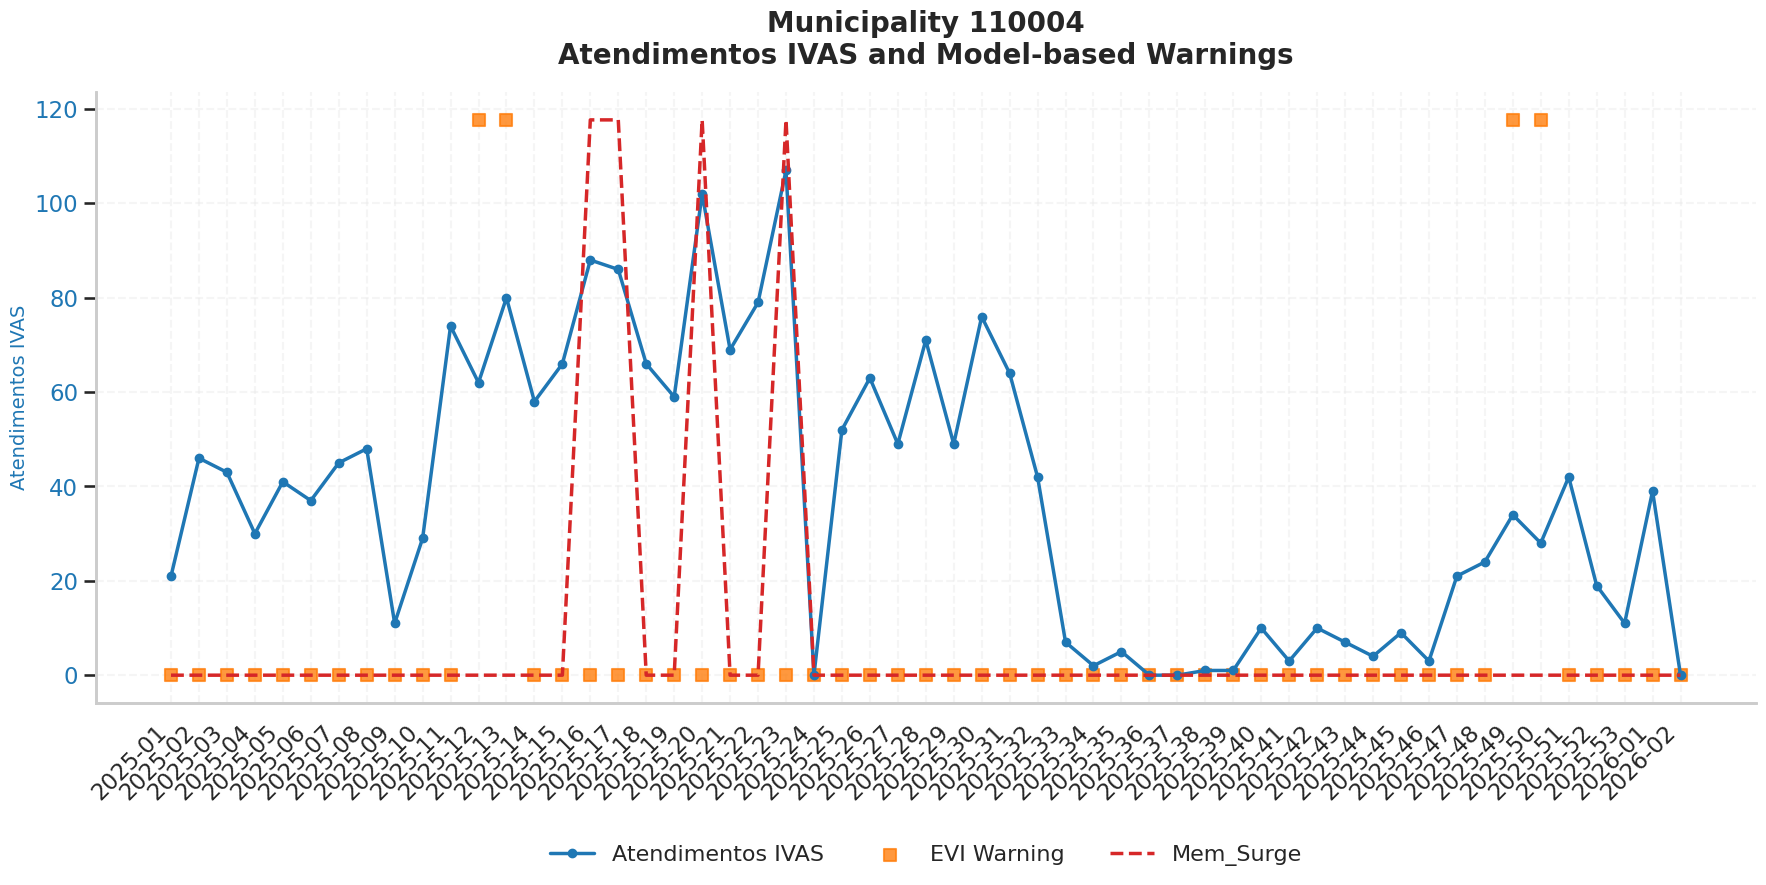

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot for one municipality ---
muni = 110004 # code
plotdf = data[data["co_ibge"] == muni].copy()

# Subtle, clean style
sns.set(style="whitegrid", context="talk")
sns.set_style("whitegrid", {"axes.grid": True, "grid.linestyle": "--", "grid.color": "0.9"})

fig, ax1 = plt.subplots(figsize=(18, 9))

# --- Main ILI line (Atend_ivas) ---
ax1.plot(
    plotdf["year_week"],
    plotdf["atend_ivas"],
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
    markersize=6,
    label="Atendimentos IVAS"
)
ax1.set_ylabel("Atendimentos IVAS", color="#1f77b4", fontsize=14)
ax1.tick_params(axis="y", labelcolor="#1f77b4")

# --- Model warnings as markers ---
ymax = plotdf["atend_ivas"].max()

warnings = [
   # ("sinal_ears_ivas", 1.05, "^", "#2ca02c", "EARS Warning"),
    ("sinal_evi_ivas",  1.10, "s", "#ff7f0e", "EVI Warning"),
    #("sinal_mmaing_ivas", 1.15, "D", "#9467bd", "MMAING Warning"),
    #("sinal_ens_ivas",  1.20, "X", "#7f7f7f", "Dashboard Ensemble")
]

for col, mult, mark, colr, label in warnings:
    ax1.scatter(
        plotdf["year_week"],
        plotdf[col] * ymax * mult,
        marker=mark,
        color=colr,
        s=80,
        alpha=0.8,
        label=label
    )

# --- Secondary axis: memory surge (hidden axis) ---
ax2 = ax1.twinx()
ax2.plot(
    plotdf["year_week"],
    plotdf["mem_surge_01"],
    color="#d62728",
    linestyle="--",
    linewidth=2.5,
    label="Mem_Surge"
)
# Make secondary axis silent
ax2.set_yticks([])
ax2.set_ylabel("")
ax2.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, labelright=False)
ax2.spines["right"].set_visible(False)

# --- Title and Legend ---
plt.title(
    f"Municipality {muni}\nAtendimentos IVAS and Model-based Warnings",
    fontsize=20, weight="bold", pad=20
)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2, labels1 + labels2,
    loc="upper center", bbox_to_anchor=(0.5, -0.2),
    ncol=3, frameon=False, fontsize=16
)

# --- Final touches ---
ax1.grid(True, which="major", linestyle="--", alpha=0.4)
ax1.grid(False, which="minor")
fig.tight_layout()
fig.autofmt_xdate(rotation=45)
sns.despine(left=False, right=True)

plt.show()


# Functions

In [10]:
def antici_count(data_res, col_warn_s1, col_warn_s2, col_code):
    """
    Function to compute anticipated counts of warnings and missed warnings 
    across different lead times per unique region.
    
    Parameters:
    data_res (pd.DataFrame): Input DataFrame.
    col_warn_s1 (str): Column name for the primary warning signal (e.g., PHC warnings).
    col_warn_s2 (str): Column name for the secondary warning signal (e.g., AIH warnings).
    col_code (str): Column name identifying the region.

    Returns:
    pd.DataFrame: Summary DataFrame with counts of early, concurrent, and missed warnings.
    """
    
    lst_count = []

    for code in data_res[col_code].unique():
    
        dta = data_res[data_res[col_code] == code].copy().reset_index()  # Use only data for the current region

        # Find sets based on PHC warnings (col_warn_s1) and AIH warnings (col_warn_s2) at different lags
        set3 = dta[(dta[col_warn_s1] == 1) & (dta[col_warn_s2].shift(-3) == 1)].index + 3
        set2 = dta[(dta[col_warn_s1] == 1) & (dta[col_warn_s2].shift(-3) == 0) & (dta[col_warn_s2].shift(-2) == 1)].index + 2
        set1 = dta[(dta[col_warn_s1] == 1) & 
                   (dta[col_warn_s2].shift(-3) == 0) & 
                   (dta[col_warn_s2].shift(-2) == 0) & 
                   (dta[col_warn_s2].shift(-1) == 1)].index + 1
        set0 = dta[(dta[col_warn_s1] == 1) & 
                   (dta[col_warn_s2] == 1) & 
                   (dta[col_warn_s2].shift(-3) == 0) & 
                   (dta[col_warn_s2].shift(-2) == 0) & 
                   (dta[col_warn_s2].shift(-1) == 0)].index
        
        # Identify True Negatives (TN)
        set_tn1 = dta[(dta[col_warn_s2] == 0) &  # AIH warning is 0
                      (dta[col_warn_s1] == 0) & 
                      (dta[col_warn_s1].shift(1).fillna(0) == 0) & 
                      (dta[col_warn_s1].shift(2).fillna(0) == 0) & 
                      (dta[col_warn_s1].shift(3).fillna(0) == 0)
                    ].index
        
        set_fp1 = dta[(dta[col_warn_s2] == 0) & 
                   ((dta[col_warn_s1] == 1) | 
                   (dta[col_warn_s1].shift(3).fillna(0) == 1) | 
                   (dta[col_warn_s1].shift(2).fillna(0) == 1) | 
                   (dta[col_warn_s1].shift(1).fillna(0) == 1))].index

        # Warnings in PHC right after an AIH warning (possibly not anticipated but concurrent)
        set1_after = dta[(dta[col_warn_s1].shift(-1) == 1) & (dta[col_warn_s2] == 1)].index
        
       

        # Compute counts of warnings at different lead times
        n3 = len(set3)
        n2 = len(set(set2) - set(set3))
        n1 = len((set(set1) - set(set3)) - set(set2))
        n0 = len(((set(set0) - set(set3)) - set(set2)) - set(set1))
        n1_after = len((((set(set1_after) - set(set3)) - set(set2)) - set(set1)) - set(set0))
        n_tn1 = len(set_tn1) 
        n_fp1 = len(set_fp1)

        # Drop all anticipated and concurrent warnings to count missed ones
        ind_drop = set(set3) | set(set2) | set(set1) | set(set0) #| set(set1_after)
        missed = dta.drop(index=ind_drop)[col_warn_s2].sum()
        
        TP = n3 + n2 + n1 + n0
        
        # outra forma de calcular o FN
        #set_FN = dta[(dta[col_warn_s2] == 1) &  
        #           (dta[col_warn_s1] == 0) & 
        #           (dta[col_warn_s1].shift(3).fillna(0) == 0) & 
        #           (dta[col_warn_s1].shift(2).fillna(0) == 0) & 
        #           (dta[col_warn_s1].shift(1).fillna(0) == 0)].index
        
        
        # Create the results dictionary for this region
        data = {
            col_code: [code],
            'n3': [n3],
            'n2': [n2],
            'n1': [n1],
            'n0': [n0],
            'n1_after': [n1_after],
            'missed': [missed],
            'TP': [TP],
            'TN1': [n_tn1], # True Negative
            'FP1': [n_fp1], # False Positive
            'FN': missed,
            'total_aih_warning': [dta[col_warn_s2].sum()]
        }

        # Append to results list
        data_output = pd.DataFrame(data)
        lst_count.append(data_output)

    # Combine all results into a single DataFrame
    df_warning_count = pd.concat(lst_count, ignore_index=True)
    
    return df_warning_count


In [11]:
def summarize_performance(df_warning_count):
    """
    Summarizes performance metrics including Sensitivity, Specificity, PPV, F1-score, POD, and FPR.
    
    Parameters:
    df_warning_count (pd.DataFrame): Dataframe containing warning counts and classification metrics.
    
    Returns:
    pd.DataFrame: Summary table with performance metrics.
    """
    # Total AIH Warnings
    total_warnings = df_warning_count.total_aih_warning.sum()
    
    # Early Detection (1 to 3 weeks)
    early_count = df_warning_count.n3.sum() + df_warning_count.n2.sum() + df_warning_count.n1.sum()
    early_rate = round((early_count * 100) / total_warnings, 1)
    
    # Timely Detection (0 week)
    timely_count = df_warning_count.n0.sum()
    timely_rate = round((timely_count * 100) / total_warnings, 1)
    
    # Missed Warnings
    missed_count = df_warning_count.missed.sum()
    missed_rate = round((missed_count * 100) / total_warnings, 1)
    
    # Classification Metrics
    TP = df_warning_count.TP.sum()
    FN = df_warning_count.FN.sum()
    TN = df_warning_count.TN1.sum()
    FP = df_warning_count.FP1.sum()

    
    # Sensitivity (Recall)
    Sensitivity = round((TP / (TP + FN)) * 100, 1) if (TP + FN) > 0 else 0
    
    # Specificity
    Specificity = round((TN / (TN + FP)) * 100, 1) if (TN + FP) > 0 else 0
    
    # Positive Predictive Value (PPV)
    PPV = round((TP / (TP + FP)) * 100, 1) if (TP + FP) > 0 else 0
    
    # F1-score
    F1_score = round(2 * (TP / (TP + FN)) * (TP / (TP + FP)) / ((TP / (TP + FN)) + (TP / (TP + FP))), 2) if ((TP / (TP + FN)) + (TP / (TP + FP))) > 0 else 0
    
    Precision = round(((TP + TN) / (TP + TN + FP + FN) * 100), 1) if (TP + TN + FP + FN) > 0 else 0

    # Probability of Detection (POD)
    POD = round(((early_count + timely_count + df_warning_count.n1_after.sum()) / total_warnings) * 100, 1)
    
    # False Positive Rate (FPR)
    FPR = round((FP / (FP + TN)) * 100, 1) if (FP + TN) > 0 else 0
    
    # Create summary DataFrame
    summary_df = pd.DataFrame({
        "Metric": ["Total Warnings", "Early Detection (1-3 weeks)", "Timely Detection (0 weeks)", "Missed Warnings",
                   "Sensitivity ", "Specificity", "PPV",  "POD", "FPR","Precision (%)"],
        "Value": [total_warnings, f"{early_count} ({early_rate}%)", f"{timely_count} ({timely_rate}%)", f"{missed_count} ({missed_rate}%)",
                   f"{Sensitivity}%", f"{Specificity}%", f"{PPV}%", f"{POD}%", f"{FPR}%", f"{Precision}%"]
    })
    
    return summary_df



In [12]:
df_warning_count = antici_count(data, 'sinal_evi_ivas', 'warning_final_mem_surge_01', 'co_ibge')

In [13]:
performance_summary = summarize_performance(df_warning_count)

In [14]:
performance_summary

,Metric,Value
0,Total Warnings,5867
1,Early Detection (1-3 weeks),2065 (35.2%)
2,Timely Detection (0 weeks),2823 (48.1%)
3,Missed Warnings,979 (16.7%)
4,Sensitivity,83.3%
5,Specificity,73.8%
6,PPV,5.9%
7,POD,87.6%
8,FPR,26.2%
9,Precision (%),74.0%
